In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

Evolving evo_3_uniform:   0%|          | 0/1000 [00:00<?, ?it/s]

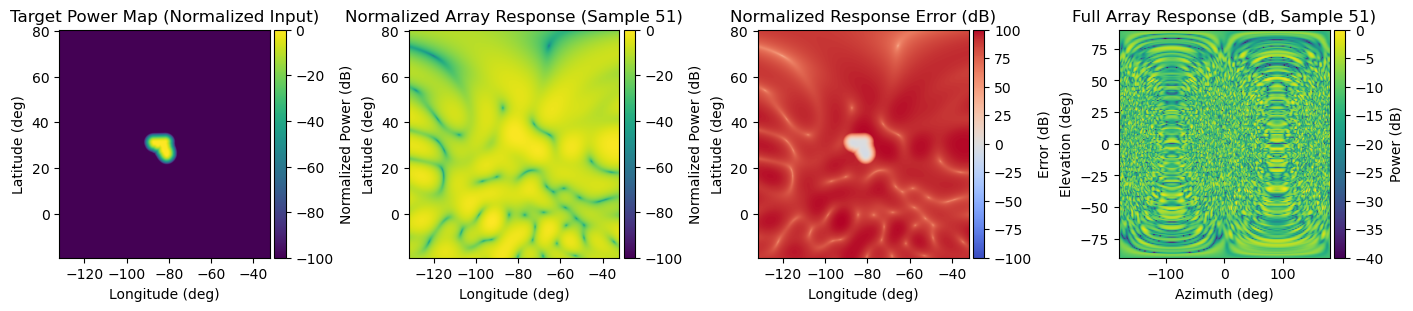

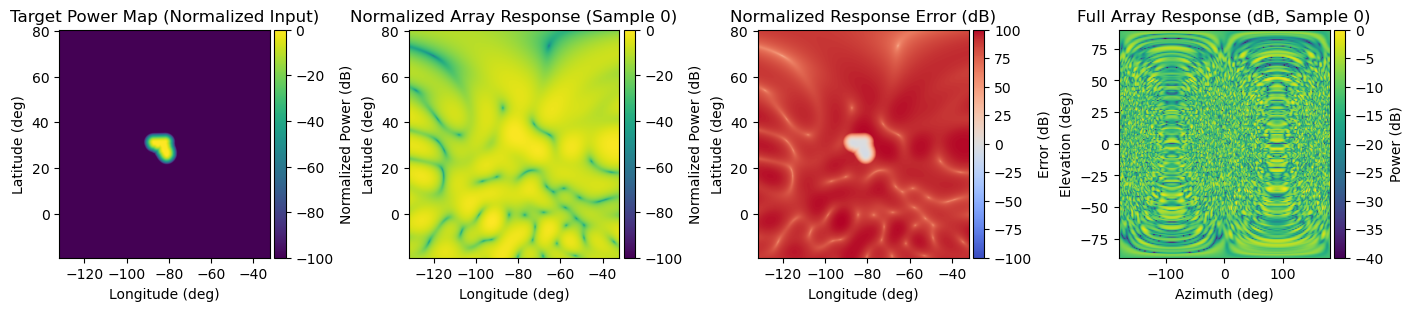

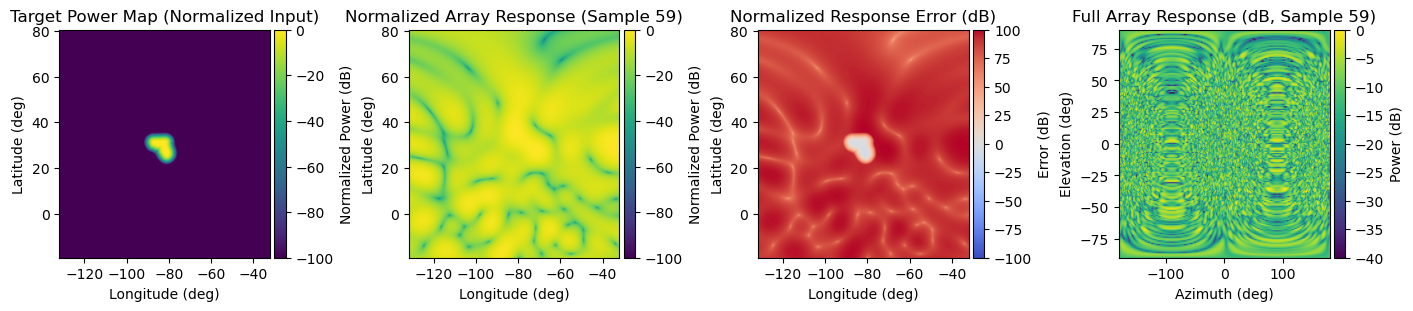

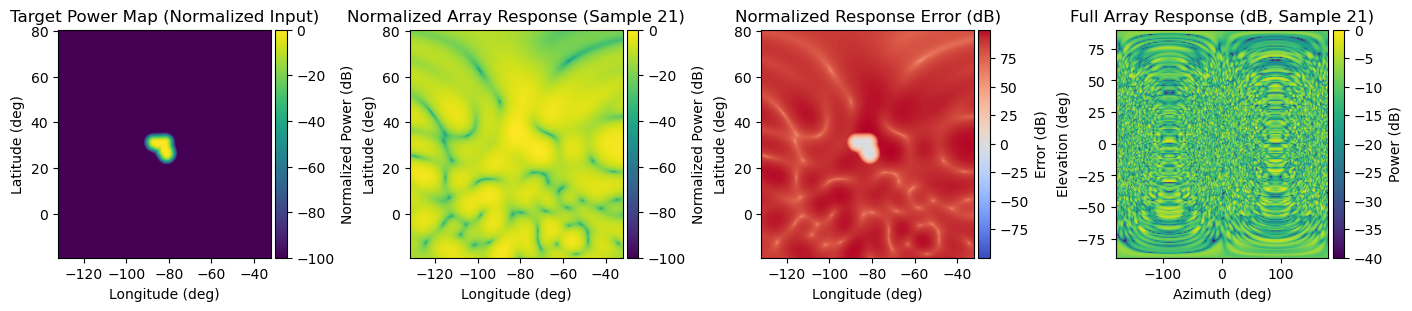

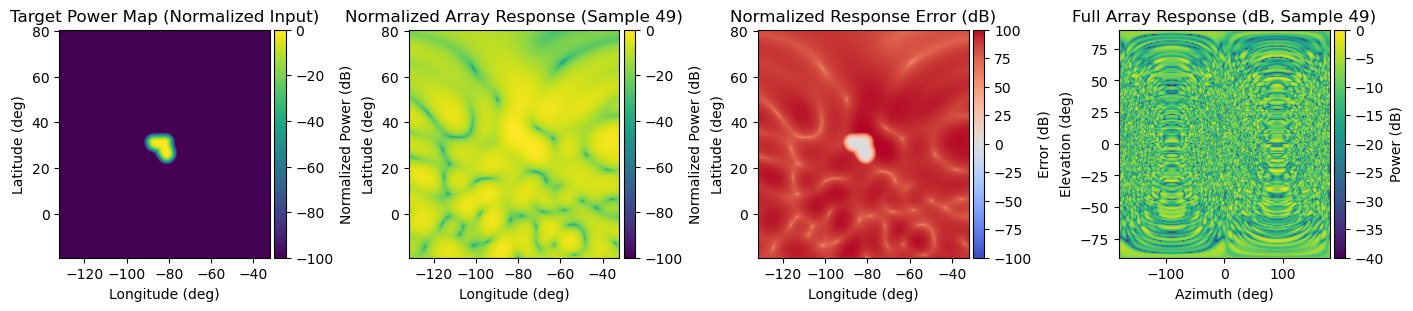

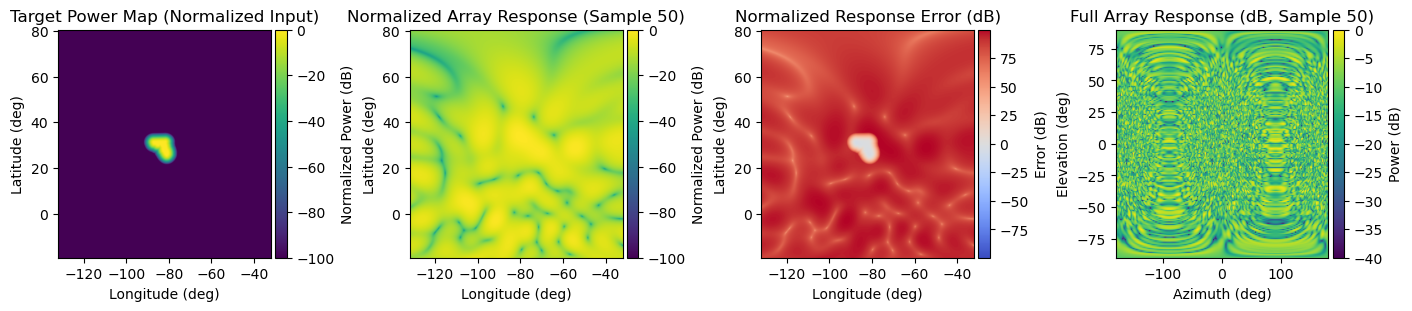

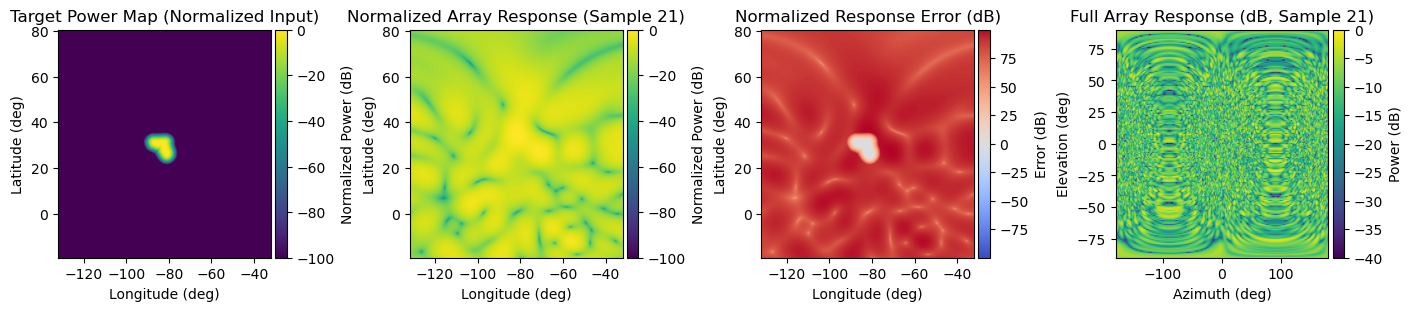

KeyboardInterrupt: 

In [ ]:
import torch
from scripts.arraySpec import ArraySpec
from train.evolve import EvolutionConfig, EvolutionController
from train.objective import LossParameters
from ui.export_target import load_target_from_pt

# Setup device and precision
dtype = torch.float32
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


# spec = ArraySpec(failRate=0.05, positionJitterSTD=0.01, phaseJitterSTD=0.1)
spec = ArraySpec(
    geometry="URA", allowedAspectRatio=[1], allowedElementCount=[1_000], altitudeRange=(3e7, 3e7)
)
config = EvolutionConfig(batchSize=50, evolutionSteps=10000)
params = LossParameters()
target = load_target_from_pt("target_spec.pt").to(device=device, dtype=dtype)
targetDecimated = target.decimate(6)


trainer = EvolutionController(
    config, targetDecimated, spec, params, experimentName="evo_3_random_fast"
)
trainer.train(dtype=dtype, device=device, plotProjection=True)